In [1]:
!pip install scikit-fuzzy matplotlib numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 15.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt
from google.colab import output
import ipywidgets as widgets
from IPython.display import display, clear_output

In [4]:
def fuzz_Mem_Func(var, typeOfMf, lst):
    '''
    Returns membership values for different membership function types.

    Parameters:
    var -- x range of variable
    typeOfMf -- type of membership function
    lst -- list of parameters for the membership function
    '''
    if typeOfMf == 'trimf':
        return fuzz.trimf(var, lst)
    elif typeOfMf == 'gaussmf':
        mean, sigma = lst
        return fuzz.gaussmf(var, mean, sigma)
    elif typeOfMf == 'gauss2mf':
        mean1, sigma1, mean2, sigma2 = lst
        return fuzz.gauss2mf(var, mean1, sigma1, mean2, sigma2)
    elif typeOfMf == 'trapmf':
        return fuzz.trapmf(var, lst)
    elif typeOfMf == 'gbellmf':
        a, b, c = lst
        return fuzz.gbellmf(var, a, b, c)

In [5]:
def create_membership_function(universe, name, mf_type, params):
    '''
    Creates and returns a membership function with the given parameters.

    Parameters:
    universe -- universe of discourse
    name -- name of the linguistic variable
    mf_type -- type of membership function
    params -- parameters for the membership function
    '''
    return {
        'name': name,
        'mf': fuzz_Mem_Func(universe, mf_type, params)
    }

In [6]:
def plot_membership_functions(universe, mfs, title):
    '''
    Plots membership functions.

    Parameters:
    universe -- universe of discourse
    mfs -- list of membership functions
    title -- title of the plot
    '''
    fig, ax = plt.subplots(figsize=(10, 4))

    for mf in mfs:
        ax.plot(universe, mf['mf'], linewidth=1.5, label=mf['name'])

    ax.set_title(title)
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

In [7]:
def create_rule_matrix(input1_terms, input2_terms, output_terms):
    '''
    Creates a rule matrix based on input and output terms.

    Parameters:
    input1_terms -- list of linguistic terms for input 1
    input2_terms -- list of linguistic terms for input 2
    output_terms -- list of linguistic terms for output

    Returns:
    rule_matrix -- 2D list containing rule indices
    '''
    # Create an interactive rule matrix using example values
    print("Define rules by selecting the appropriate output for each input combination:")
    print("Output terms: ")
    for i, term in enumerate(output_terms):
        print(f"{i+1}. {term['name']}")

    rule_matrix = []
    for i in range(len(input1_terms)):
        row = []
        for j in range(len(input2_terms)):
            # In a real interactive environment, you would get user input here
            # For demonstration, we'll use a simple rule: sum of indices modulo len(output_terms)
            rule_idx = (i + j) % len(output_terms)
            row.append(rule_idx)
            print(f"Rule: IF input1 is {input1_terms[i]['name']} AND input2 is {input2_terms[j]['name']} THEN output is {output_terms[rule_idx]['name']}")
        rule_matrix.append(row)

    return rule_matrix

In [8]:

def fuzzy_inference(input1_val, input2_val, universe1, universe2, output_universe,
                    input1_mfs, input2_mfs, output_mfs, rule_matrix):
    '''
    Performs fuzzy inference and defuzzification.

    Parameters:
    input1_val -- crisp value for input 1
    input2_val -- crisp value for input 2
    universe1 -- universe of discourse for input 1
    universe2 -- universe of discourse for input 2
    output_universe -- universe of discourse for output
    input1_mfs -- membership functions for input 1
    input2_mfs -- membership functions for input 2
    output_mfs -- membership functions for output
    rule_matrix -- rule matrix

    Returns:
    result -- defuzzified output value
    '''
    # Step 1: Fuzzify inputs
    input1_fuzzified = []
    for mf in input1_mfs:
        degree = fuzz.interp_membership(universe1, mf['mf'], input1_val)
        input1_fuzzified.append(degree)

    input2_fuzzified = []
    for mf in input2_mfs:
        degree = fuzz.interp_membership(universe2, mf['mf'], input2_val)
        input2_fuzzified.append(degree)

    # Step 2: Apply fuzzy rules
    rule_outputs = []
    activated_mfs = []

    # Initialize plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_xlabel('Output Universe')
    ax.set_ylabel('Membership Degree')
    ax.set_title('Rule Outputs and Aggregation')

    # Zero-like array for plotting
    zero_like = np.zeros_like(output_universe)

    # Apply each rule
    for i in range(len(input1_mfs)):
        for j in range(len(input2_mfs)):
            # Apply the AND operator (minimum)
            rule_strength = min(input1_fuzzified[i], input2_fuzzified[j])

            # Get the corresponding output membership function
            output_idx = rule_matrix[i][j]
            output_mf = output_mfs[output_idx]['mf']

            # Apply implication (minimum)
            activated_mf = np.fmin(rule_strength, output_mf)

            # Store the activated membership function
            if rule_strength > 0:  # Only consider rules with non-zero activation
                rule_outputs.append(activated_mf)
                activated_mfs.append(output_mfs[output_idx]['mf'])

                # Plot this rule's output
                ax.fill_between(output_universe, zero_like, activated_mf, alpha=0.3)
                ax.plot(output_universe, output_mf, linestyle='--', alpha=0.5)

    # Step 3: Aggregate outputs
    if rule_outputs:
        aggregated = np.max(np.vstack(rule_outputs), axis=0)
        ax.fill_between(output_universe, zero_like, aggregated, alpha=0.7, color='orange')
        ax.plot(output_universe, aggregated, color='red', linewidth=2, label='Aggregated Output')
    else:
        aggregated = zero_like

    # Step 4: Defuzzify
    if np.any(aggregated):
        result = fuzz.defuzz(output_universe, aggregated, 'centroid')
        result_activation = fuzz.interp_membership(output_universe, aggregated, result)

        # Plot the defuzzified value
        ax.vlines(result, 0, result_activation, color='k', linestyle='-', linewidth=2, label=f'Output: {result:.2f}')
    else:
        result = None

    ax.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return result


In [9]:
# Temperature universe (in Celsius)
temp_universe = np.arange(0, 41, 1)

# Temperature change rate universe (in Celsius per minute)
rate_universe = np.arange(-5, 6, 0.5)

# Heating power universe (in percentage)
power_universe = np.arange(0, 101, 1)

# ### Define membership functions

# Temperature membership functions
temp_mfs = [
    create_membership_function(temp_universe, 'Cold', 'trimf', [0, 0, 20]),
    create_membership_function(temp_universe, 'Comfortable', 'trimf', [15, 22, 30]),
    create_membership_function(temp_universe, 'Hot', 'trimf', [25, 40, 40])
]

# Temperature change rate membership functions
rate_mfs = [
    create_membership_function(rate_universe, 'Decreasing', 'trimf', [-5, -2, 0]),
    create_membership_function(rate_universe, 'Stable', 'trimf', [-1, 0, 1]),
    create_membership_function(rate_universe, 'Increasing', 'trimf', [0, 2, 5])
]

# Heating power membership functions
power_mfs = [
    create_membership_function(power_universe, 'Low', 'trimf', [0, 0, 40]),
    create_membership_function(power_universe, 'Medium', 'trimf', [20, 50, 80]),
    create_membership_function(power_universe, 'High', 'trimf', [60, 100, 100])
]

Temperature Membership Functions:


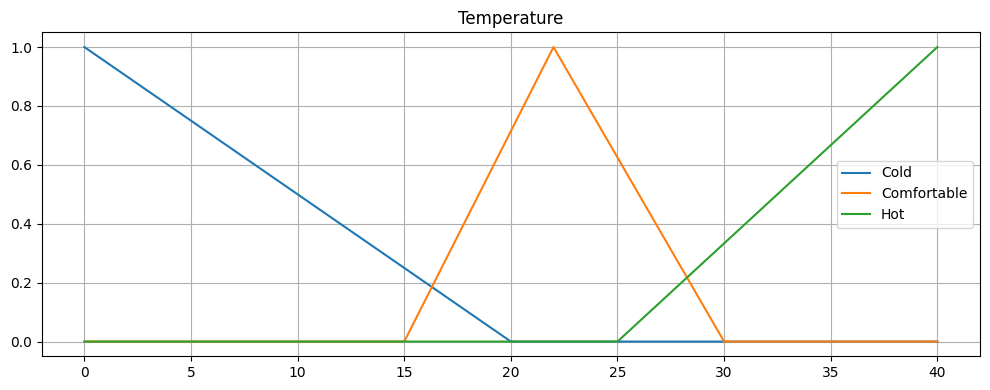

In [10]:
print("Temperature Membership Functions:")
plot_membership_functions(temp_universe, temp_mfs, 'Temperature')


Temperature Change Rate Membership Functions:


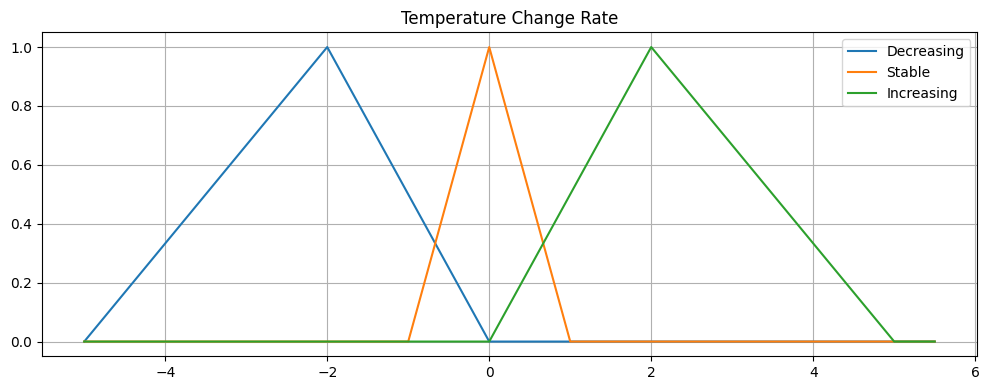

In [11]:
print("Temperature Change Rate Membership Functions:")
plot_membership_functions(rate_universe, rate_mfs, 'Temperature Change Rate')

Heating Power Membership Functions:


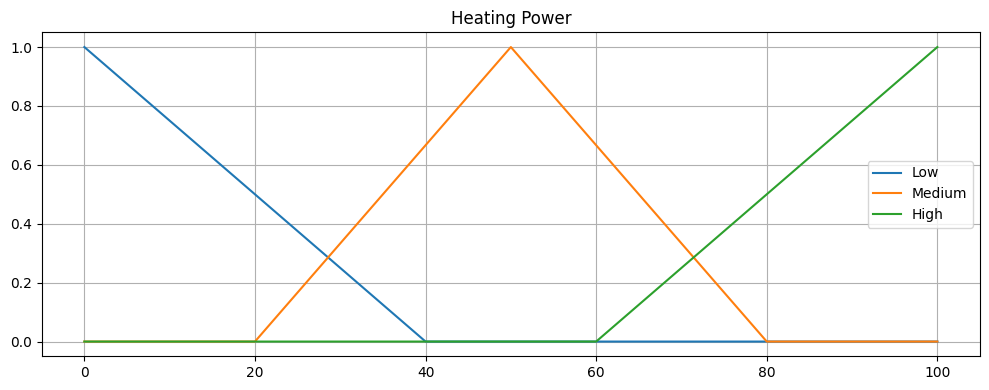

In [12]:
print("Heating Power Membership Functions:")
plot_membership_functions(power_universe, power_mfs, 'Heating Power')

In [13]:
rule_matrix = [
    # Current Temp: Cold (rows) × Change Rate: Decreasing, Stable, Increasing (columns)
    [2, 2, 1],  # High, High, Medium
    # Current Temp: Comfortable
    [2, 1, 0],  # High, Medium, Low
    # Current Temp: Hot
    [1, 0, 0]   # Medium, Low, Low
]

print("\nFuzzy Rules:")
rule_names = [mf['name'] for mf in power_mfs]
for i, temp_mf in enumerate(temp_mfs):
    for j, rate_mf in enumerate(rate_mfs):
        print(f"IF Temperature is {temp_mf['name']} AND Rate is {rate_mf['name']} THEN Power is {power_mfs[rule_matrix[i][j]]['name']}")


Fuzzy Rules:
IF Temperature is Cold AND Rate is Decreasing THEN Power is High
IF Temperature is Cold AND Rate is Stable THEN Power is High
IF Temperature is Cold AND Rate is Increasing THEN Power is Medium
IF Temperature is Comfortable AND Rate is Decreasing THEN Power is High
IF Temperature is Comfortable AND Rate is Stable THEN Power is Medium
IF Temperature is Comfortable AND Rate is Increasing THEN Power is Low
IF Temperature is Hot AND Rate is Decreasing THEN Power is Medium
IF Temperature is Hot AND Rate is Stable THEN Power is Low
IF Temperature is Hot AND Rate is Increasing THEN Power is Low
